In [1]:
import PcmPy as pcm
import numpy as np
import matplotlib.pyplot as plt
import globals as gl
import os
from vis import plot_theta_lfp, plot_theta_lfp_mean, plot_D_lfp

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
path_lfp = os.path.join(gl.baseDir, 'smp2', 'LFPs', gl.pcmDir)
monkey = 'Pert'
freqs = ['delta', 'theta', 'alpha-beta', 'alpha', 'beta','gamma']

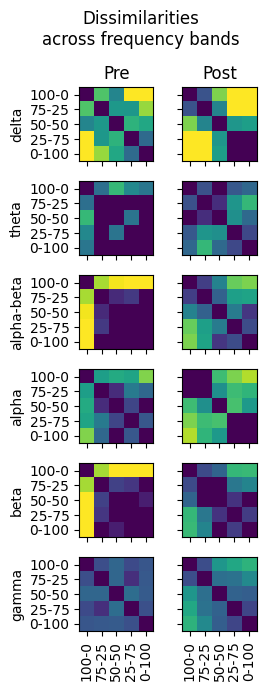

In [10]:
fig, axs = plt.subplots( len(freqs), 2, sharex='col', sharey=True, figsize=(3, 7))

for f, freq in enumerate(freqs):
    theta_in = np.load(os.path.join(path_lfp, f'theta_in.lfp.{monkey}.PMd.{freq}.aligned.plan.npy'))
    G_obs = np.load(os.path.join(path_lfp, f'G_obs.lfp.{monkey}.PMd.{freq}.aligned.plan.npy'))
    ax, h = plot_D_lfp(f, 0, axs, G_obs[:101].mean(axis=0), list(gl.regressor_mapping.keys())[:5], vmin=0, vmax=.3, sqrt=True)
    ax.set_ylabel(freq)
    ax, _ = plot_D_lfp(f, 1, axs, G_obs[101:].mean(axis=0), list(gl.regressor_mapping.keys())[:5], vmin=0, vmax=.3, sqrt=True)
    if f==0:
        axs[f, 0].set_title('Pre')
        axs[f, 1].set_title('Post')

fig.suptitle('Dissimilarities\nacross frequency bands')
fig.tight_layout()

plt.show()

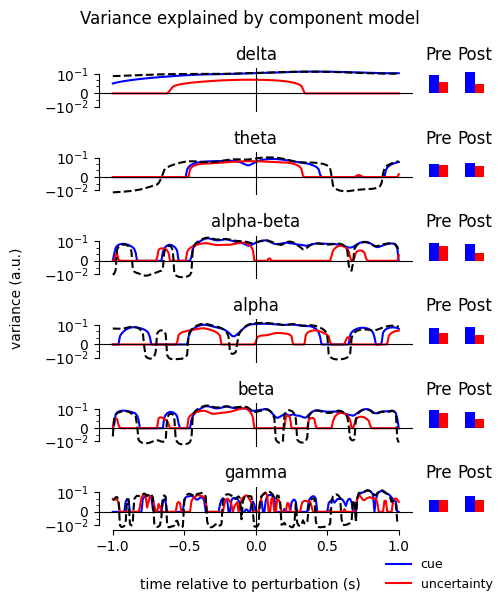

In [4]:
fig, axs = plt.subplots(len(freqs),3, sharex='col', sharey=True, figsize=(5, 6), gridspec_kw={'width_ratios': [3, .2, .2]})

tAx = np.linspace(-1, 1, 201)

for f, freq in enumerate(freqs):
    theta_in = np.load(os.path.join(path_lfp, f'theta_in.lfp.{monkey}.PMd.{freq}.aligned.plan.npy'))
    G_obs = np.load(os.path.join(path_lfp, f'G_obs.lfp.{monkey}.PMd.{freq}.aligned.plan.npy'))
    tr = np.trace(G_obs, axis1=1, axis2=2)
    ax = plot_theta_lfp(f, axs, tAx, theta_in, tr, 2, color=['blue', 'red'])
    ax.set_title(freq)
    ax.spines['left'].set_bounds(-.01, .1)
    ax.set_yscale('symlog', linthresh=0.001)
    ax.set_yticks([-.01, 0, .1])

    ax = plot_theta_lfp_mean(f, 1, axs, tAx, theta_in, tr, 2, range(0, 101), color=['blue', 'red'])
    ax.set_title('Pre')
    ax = plot_theta_lfp_mean(f, 2, axs, tAx, theta_in, tr, 2, range(101, 201), color=['blue', 'red'])
    ax.set_title('Post')

fig.supylabel('variance (a.u.)', fontsize='medium')
fig.supxlabel('time relative to perturbation (s)', fontsize='medium')
fig.legend(['cue', 'uncertainty'], loc='lower right', fontsize=9, frameon=False)
fig.suptitle('Variance explained by component model')

fig.tight_layout()

plt.show()

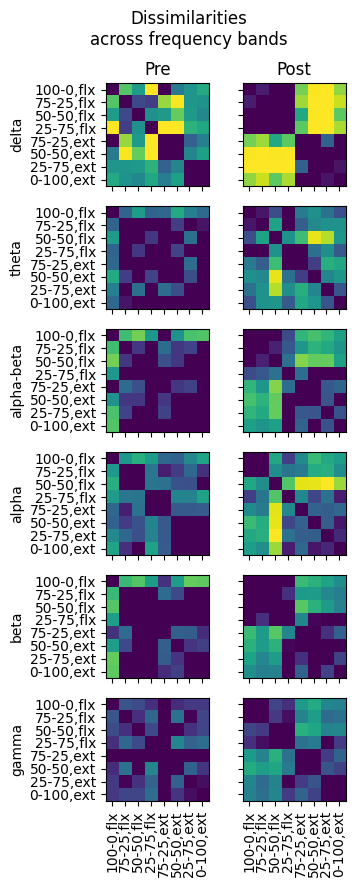

In [15]:
fig, axs = plt.subplots( len(freqs), 2, sharex='col', sharey=True, figsize=(4, 9))

conds = ['100-0,flx', '75-25,flx', '50-50,flx', '25-75,flx', '75-25,ext', '50-50,ext', '25-75,ext', '0-100,ext',]

for f, freq in enumerate(freqs):
    G_obs = np.load(os.path.join(path_lfp, f'G_obs.lfp.{monkey}.PMd.{freq}.aligned.exec.npy'))
    ax, h = plot_D_lfp(f, 0, axs, G_obs[:101].mean(axis=0), conds, vmin=0, vmax=.2, sqrt=True)
    ax.set_ylabel(freq)
    ax, _ = plot_D_lfp(f, 1, axs, G_obs[101:].mean(axis=0), conds, vmin=0, vmax=.2, sqrt=True)
    if f==0:
        axs[f, 0].set_title('Pre')
        axs[f, 1].set_title('Post')

fig.suptitle('Dissimilarities\nacross frequency bands')
fig.tight_layout()

plt.show()

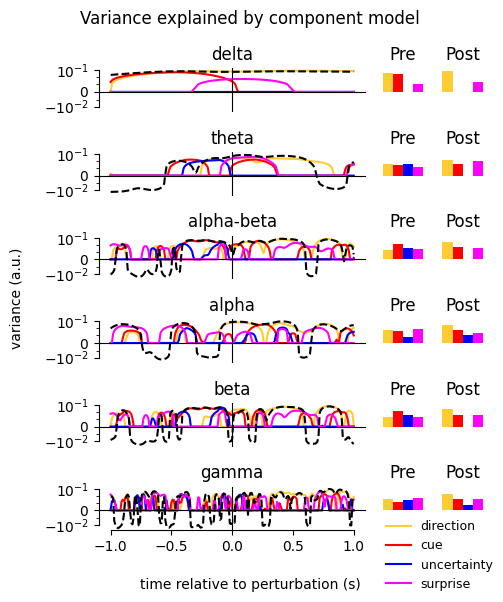

In [6]:
fig, axs = plt.subplots(len(freqs),3, sharex='col', sharey=True, figsize=(5, 6), gridspec_kw={'width_ratios': [3, .5, .5]})

tAx = np.linspace(-1, 1, 201)

for f, freq in enumerate(freqs):
    theta_in = np.load(os.path.join(path_lfp, f'theta_in.lfp.{monkey}.PMd.{freq}.aligned.exec.npy'))
    G_obs = np.load(os.path.join(path_lfp, f'G_obs.lfp.{monkey}.PMd.{freq}.aligned.exec.npy'))
    tr = np.trace(G_obs, axis1=1, axis2=2)
    ax = plot_theta_lfp(f, axs, tAx, theta_in, tr, 4, color=['#FFCC33', 'red', 'blue', 'magenta'])
    ax.set_title(freq)
    ax.spines['left'].set_bounds(-.01, .1)
    ax.set_yscale('symlog', linthresh=0.001)
    ax.set_yticks([-.01, 0, .1])

    ax = plot_theta_lfp_mean(f, 1, axs, tAx, theta_in, tr, 4, range(0, 101), color=['#FFCC33', 'red', 'blue', 'magenta'])
    ax.set_title('Pre')
    ax = plot_theta_lfp_mean(f, 2, axs, tAx, theta_in, tr, 4, range(101, 201), color=['#FFCC33', 'red', 'blue', 'magenta'])
    ax.set_title('Post')

fig.supylabel('variance (a.u.)', fontsize='medium')
fig.supxlabel('time relative to perturbation (s)', fontsize='medium')
fig.legend(['direction','cue', 'uncertainty', 'surprise'],
           loc='lower right', ncol=1, fontsize=9, frameon=False)
fig.suptitle('Variance explained by component model')
fig.tight_layout()

plt.show()